### Stock Prediction Machine Learning Model Notebook

## Phase 1 : Importing Necessary Libraries + Importing Data + Data Preperation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df_TCS = pd.read_csv(r"Data\nestle\NESTLEIND.NS_data.csv")

In [3]:
df_TCS.info()

<class 'pandas.DataFrame'>
RangeIndex: 2759 entries, 0 to 2758
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   2759 non-null   str  
 1   Close   2758 non-null   str  
 2   High    2758 non-null   str  
 3   Low     2758 non-null   str  
 4   Open    2758 non-null   str  
 5   Volume  2758 non-null   str  
dtypes: str(6)
memory usage: 129.5 KB


In [4]:
df_TCS.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-01,276.72540283203125,280.31918993203675,275.93920258934867,279.66219183063356,60500
3,2015-01-02,277.31884765625,278.85184288545355,274.0141286927371,274.0141286927371,136860
4,2015-01-05,277.4678039550781,279.0051837346205,275.5011939859911,279.0051837346205,213800


In [5]:
df_TCS.describe()

,Price,Close,High,Low,Open,Volume
count,2759,2758,2758,2758,2758,2758
unique,2759,2744,2758,2756,2758,2735
top,Ticker,271.02777099609375,NESTLEIND.NS,1278.0,NESTLEIND.NS,524860
freq,1,2,1,3,1,2


In [6]:
df_TCS = df_TCS.rename(columns={'Price':'Date'})

In [7]:
df_TCS = df_TCS.iloc[2:].reset_index(drop=True)

#### Changing type of Data to Decimal and Numeric

In [8]:
df_TCS['Date'] = pd.to_datetime(df_TCS['Date'])

decimal_values = ["Close", "High", "Low", "Open"]
numeric_values =["Volume"]

for i in decimal_values:
    df_TCS[i] = df_TCS[i].astype(float)

for j in numeric_values:
    df_TCS[j] = pd.to_numeric(df_TCS[j])

In [9]:
# Sorting Values By Date

df_TCS = df_TCS.sort_values(by="Date").reset_index(drop=True)

# Volume Ratio over a 20 days window

In [10]:
df_TCS['Volume_Ratio'] = df_TCS['Volume'] / df_TCS['Volume'].rolling(window=20).mean()

In [11]:
df_TCS.corr()

,Date,Close,High,Low,Open,Volume,Volume_Ratio
Date,1.000000,0.974254,0.974057,0.974237,0.974026,0.141353,-0.015732
Close,0.974254,1.000000,0.999828,0.999808,0.999581,0.171614,-0.013008
High,0.974057,0.999828,1.000000,0.999724,0.999776,0.176931,-0.008845
Low,0.974237,0.999808,0.999724,1.000000,0.999785,0.164606,-0.019480
Open,0.974026,0.999581,0.999776,0.999785,1.000000,0.169977,-0.015620
Volume,0.141353,0.171614,0.176931,0.164606,0.169977,1.000000,0.756128
Volume_Ratio,-0.015732,-0.013008,-0.008845,-0.019480,-0.015620,0.756128,1.000000


#### Calculating Returns on Stock Price

In [12]:
df_TCS['Daily_Returns'] = df_TCS['Close'].pct_change()

### Calculating Moving Averages Across the Range

In [13]:
df_TCS['MA_Week'] = df_TCS['Close'].rolling(window=7).mean()

df_TCS['MA_Month'] = df_TCS['Close'].rolling(window=30).mean()

df_TCS['MA_3Months'] = df_TCS['Close'].rolling(window=90).mean()


In [14]:
df_TCS.corr()

,Date,Close,High,Low,Open,Volume,Volume_Ratio,Daily_Returns,MA_Week,MA_Month,MA_3Months
Date,1.000000,0.974254,0.974057,0.974237,0.974026,0.141353,-0.015732,-0.005297,0.974694,0.976140,0.979196
Close,0.974254,1.000000,0.999828,0.999808,0.999581,0.171614,-0.013008,0.004976,0.999243,0.996654,0.992017
High,0.974057,0.999828,1.000000,0.999724,0.999776,0.176931,-0.008845,-0.005381,0.999353,0.996785,0.992129
Low,0.974237,0.999808,0.999724,1.000000,0.999785,0.164606,-0.019480,-0.006640,0.999378,0.996751,0.992024
Open,0.974026,0.999581,0.999776,0.999785,1.000000,0.169977,-0.015620,-0.018100,0.999485,0.996921,0.992210
Volume,0.141353,0.171614,0.176931,0.164606,0.169977,1.000000,0.756128,0.097841,0.168583,0.164333,0.149843
Volume_Ratio,-0.015732,-0.013008,-0.008845,-0.019480,-0.015620,0.756128,1.000000,0.108333,-0.014327,-0.016083,-0.014945
Daily_Returns,-0.005297,0.004976,-0.005381,-0.006640,-0.018100,0.097841,0.108333,1.000000,-0.017038,-0.015031,-0.014730
MA_Week,0.974694,0.999243,0.999353,0.999378,0.999485,0.168583,-0.014327,-0.017038,1.000000,0.997923,0.993188
MA_Month,0.976140,0.996654,0.996785,0.996751,0.996921,0.164333,-0.016083,-0.015031,0.997923,1.000000,0.996584


### The correlation of Above features is very high so we must avoid them and we are using their ratios

In [15]:
df_TCS['MA_Week_Ratio'] = df_TCS['Close'] / df_TCS['MA_Week']
df_TCS['MA_Month_Ratio'] = df_TCS['Close'] / df_TCS['MA_Month']
df_TCS['MA_3Months_Ratio'] = df_TCS['Close'] / df_TCS['MA_3Months']

In [16]:
df_TCS.corr()

,Date,Close,High,Low,Open,Volume,Volume_Ratio,Daily_Returns,MA_Week,MA_Month,MA_3Months,MA_Week_Ratio,MA_Month_Ratio,MA_3Months_Ratio
Date,1.000000,0.974254,0.974057,0.974237,0.974026,0.141353,-0.015732,-0.005297,0.974694,0.976140,0.979196,-0.008220,0.002016,-0.007847
Close,0.974254,1.000000,0.999828,0.999808,0.999581,0.171614,-0.013008,0.004976,0.999243,0.996654,0.992017,0.012727,0.035972,0.037283
High,0.974057,0.999828,1.000000,0.999724,0.999776,0.176931,-0.008845,-0.005381,0.999353,0.996785,0.992129,0.006393,0.032727,0.035463
Low,0.974237,0.999808,0.999724,1.000000,0.999785,0.164606,-0.019480,-0.006640,0.999378,0.996751,0.992024,0.005431,0.032955,0.035956
Open,0.974026,0.999581,0.999776,0.999785,1.000000,0.169977,-0.015620,-0.018100,0.999485,0.996921,0.992210,-0.002122,0.028586,0.033102
Volume,0.141353,0.171614,0.176931,0.164606,0.169977,1.000000,0.756128,0.097841,0.168583,0.164333,0.149843,0.012415,-0.014970,-0.021632
Volume_Ratio,-0.015732,-0.013008,-0.008845,-0.019480,-0.015620,0.756128,1.000000,0.108333,-0.014327,-0.016083,-0.014945,0.014070,-0.026801,-0.023841
Daily_Returns,-0.005297,0.004976,-0.005381,-0.006640,-0.018100,0.097841,0.108333,1.000000,-0.017038,-0.015031,-0.014730,0.627453,0.306184,0.181541
MA_Week,0.974694,0.999243,0.999353,0.999378,0.999485,0.168583,-0.014327,-0.017038,1.000000,0.997923,0.993188,-0.021808,0.013679,0.023825
MA_Month,0.976140,0.996654,0.996785,0.996751,0.996921,0.164333,-0.016083,-0.015031,0.997923,1.000000,0.996584,-0.028228,-0.037189,-0.017837


### MACD (Moving Average Convergence Divergence)

##### Exponential Moving average

In [17]:
ema_12 = df_TCS['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df_TCS['Close'].ewm(span=26, adjust=False).mean()

In [18]:
df_TCS['MACD'] = ema_12 - ema_26

In [19]:
df_TCS['MACD_Signal'] = df_TCS['MACD'].ewm(span=9, adjust=False).mean()

In [20]:
# Volatility to Measure the High Risk Periods
df_TCS['volatility'] = df_TCS['Daily_Returns'].rolling(window=20).std()


In [21]:
mean_volatility = df_TCS['volatility'].mean()

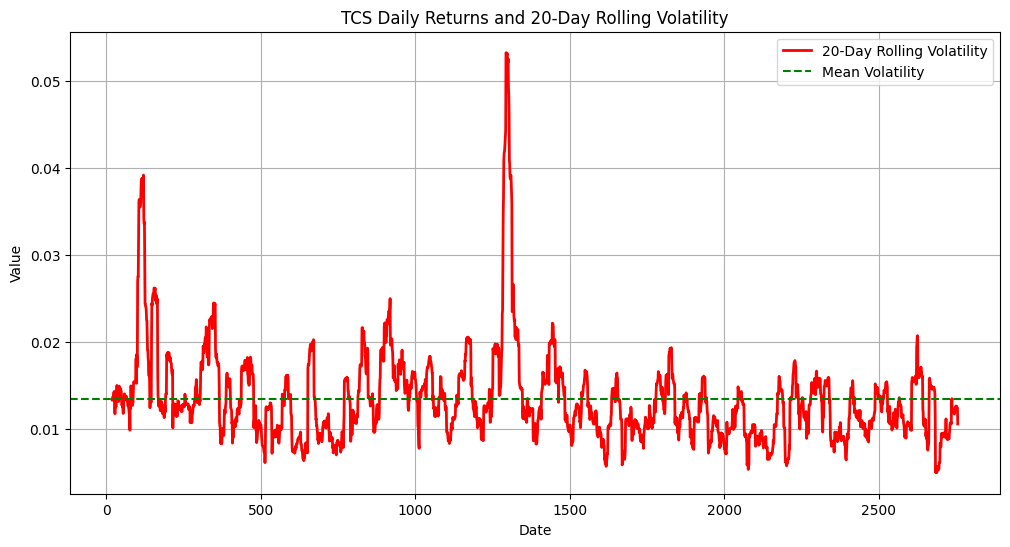

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df_TCS.index, df_TCS['volatility'], label='20-Day Rolling Volatility', color='red', linewidth=2)
plt.axhline(mean_volatility, color='green',linestyle='--', label='Mean Volatility')
plt.title('TCS Daily Returns and 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)


In [23]:
# Computing RSI (Relative Strength Index) , it measures speed and magnitude of Price Movements

# RSI compares (Average Gains VS Average Losses)

delta = df_TCS['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()

rs = avg_gain/avg_loss

df_TCS['RSI'] = 100-(100/(1+rs))

In [24]:
EMA_12 = df_TCS['Close'].ewm(span=12, adjust=False).mean()
EMA_26 = df_TCS['Close'].ewm(span=26, adjust=False).mean()
MACD_Line = EMA_12 - EMA_26
Signal_Line = MACD_Line.ewm(span=9, adjust=False).mean()
df_TCS['MACD_Histogram'] = MACD_Line - Signal_Line

### Bollinger Band Indicator

In [25]:
BB_Middle = df_TCS['Close'].rolling(window=20).mean()
BB_Std = df_TCS['Close'].rolling(window=20).std()
BB_Upper = BB_Middle + (2 * BB_Std)
BB_Lower = BB_Middle - (2 * BB_Std)

df_TCS['BB_Position'] = (df_TCS['Close'] - BB_Middle) / (2 * BB_Std)

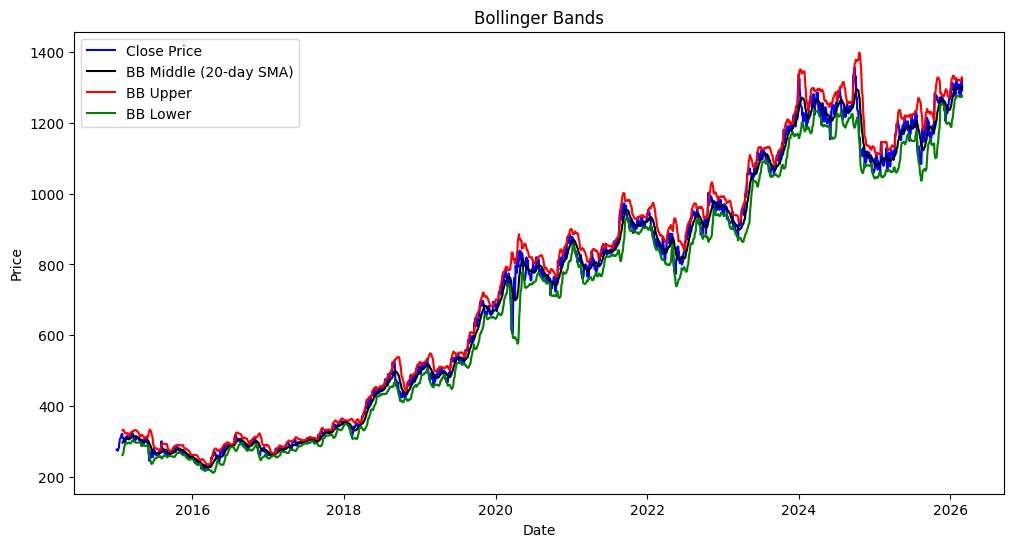

In [26]:
plt.figure(figsize=(12,6))

plt.plot(df_TCS['Date'], df_TCS['Close'], label='Close Price', color='blue')
plt.plot(df_TCS['Date'], BB_Middle, label='BB Middle (20-day SMA)', color='black')
plt.plot(df_TCS['Date'], BB_Upper, label='BB Upper', color='red')
plt.plot(df_TCS['Date'], BB_Lower, label='BB Lower', color='green')

plt.fill_between(df_TCS['Date'], BB_Upper, BB_Lower, color='lightgray', alpha=0.3)

plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


#### Due to Size of Data Range, the visualization is not too much beneficial on a 10 year time period scale . So Visualizing through Interactive plot based on plotly

In [27]:
import plotly.graph_objects as go

fig = go.Figure()


fig.add_trace(go.Scatter(x=df_TCS['Date'], y=BB_Upper, name='Upper Band', line=dict(color='red', width=1)))
fig.add_trace(go.Scatter(x=df_TCS['Date'], y=BB_Lower, name='Lower Band', line=dict(color='green', width=1), fill='tonexty', fillcolor='rgba(128, 128, 128, 0.2)'))
fig.add_trace(go.Scatter(x=df_TCS['Date'], y=BB_Middle, name='Middle Band', line=dict(color='black', width=1, dash='dash')))
fig.add_trace(go.Scatter(x=df_TCS['Date'], y=df_TCS['Close'], name='Close Price', line=dict(color='blue', width=2)))



fig.add_trace(go.Scatter(x=df_TCS['Date'], y=BB_Upper, name='Upper Band', line=dict(color='red', width=1)))
fig.add_trace(go.Scatter(x=df_TCS['Date'], y=BB_Lower, name='Lower Band', line=dict(color='green', width=1), fill='tonexty', fillcolor='rgba(128, 128, 128, 0.2)'))
fig.add_trace(go.Scatter(x=df_TCS['Date'], y=BB_Middle, name='Middle Band', line=dict(color='black', width=1, dash='dash')))
fig.add_trace(go.Scatter(x=df_TCS['Date'], y=df_TCS['Close'], name='Close Price', line=dict(color='blue', width=2)))

In [28]:
'''

Bollinger Bands provide a powerful way for a machine learning model to predict this target 
by answering two critical questions:

Is the price "Overextended"? (Mean Reversion) If your BB_Position feature approaches or exceeds 1.0,
the stock is hitting the Upper Bollinger Band. In many market environments, 
this indicates the stock is overbought and due for a pullback. 
Therefore, a high BB_Position today should increase the probability that the model predicts a 
Target of 0 (Down) for tomorrow. Conversely, a BB_Position near -1.0 (touching the lower band) 
often precedes a bounce, increasing the probability of a Target of 1 (Up).

Is a Massive Move Coming? (Volatility Breakout) When the bands get very tight (low volatility), 
it often precedes an explosive move. While the bands themselves don't predict the direction of the 
breakout, when combined with other momentum indicators (like your MACD_Histogram or RSI), 
a tight band followed by a sudden widening can signal the start of a strong new trend, making the 
model highly confident in predicting a sequence of 1s or 0s.

'''

'\n\nBollinger Bands provide a powerful way for a machine learning model to predict this target \nby answering two critical questions:\n\nIs the price "Overextended"? (Mean Reversion) If your BB_Position feature approaches or exceeds 1.0,\nthe stock is hitting the Upper Bollinger Band. In many market environments, \nthis indicates the stock is overbought and due for a pullback. \nTherefore, a high BB_Position today should increase the probability that the model predicts a \nTarget of 0 (Down) for tomorrow. Conversely, a BB_Position near -1.0 (touching the lower band) \noften precedes a bounce, increasing the probability of a Target of 1 (Up).\n\nIs a Massive Move Coming? (Volatility Breakout) When the bands get very tight (low volatility), \nit often precedes an explosive move. While the bands themselves don\'t predict the direction of the \nbreakout, when combined with other momentum indicators (like your MACD_Histogram or RSI), \na tight band followed by a sudden widening can signal 

### Average True Range

In [29]:
''' ATR measures the absolute size of a stock's daily price moves, 
factoring in "gaps" between trading days. '''



' ATR measures the absolute size of a stock\'s daily price moves, \nfactoring in "gaps" between trading days. '

In [30]:
prev_close = df_TCS['Close'].shift(1)
tr1 = df_TCS['High'] - df_TCS['Low']
tr2 = (df_TCS['High'] - prev_close).abs()
tr3 = (df_TCS['Low'] - prev_close).abs()
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
df_TCS['ATR_Ratio'] = true_range.rolling(window=14).mean() / df_TCS['Close']

### Creating Prediction Target

In [31]:
df_TCS['Next_Day_Return'] = df_TCS['Daily_Returns'].shift(-1)

threshold = 0
df_TCS['Target'] = np.nan
df_TCS.loc[df_TCS['Next_Day_Return'] > threshold, 'Target'] = 1
df_TCS.loc[df_TCS['Next_Day_Return'] < -threshold, 'Target'] = 0

In [32]:
df_TCS['Target'].isnull().sum()

np.int64(4)

#### Lag Features

In [33]:
# Lag Features
df_TCS['Return_Lag1'] = df_TCS['Daily_Returns'].shift(1)
df_TCS['Return_Lag2'] = df_TCS['Daily_Returns'].shift(2)
df_TCS['Return_Lag3'] = df_TCS['Daily_Returns'].shift(3)
df_TCS['RSI_Lag1'] = df_TCS['RSI'].shift(1)

In [34]:
df_TCS['Day_of_Week'] = df_TCS['Date'].dt.dayofweek

In [35]:
df_TCS = df_TCS.dropna()
df_TCS.isnull().sum()

Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
Volume_Ratio        0
Daily_Returns       0
MA_Week             0
MA_Month            0
MA_3Months          0
MA_Week_Ratio       0
MA_Month_Ratio      0
MA_3Months_Ratio    0
MACD                0
MACD_Signal         0
volatility          0
RSI                 0
MACD_Histogram      0
BB_Position         0
ATR_Ratio           0
Next_Day_Return     0
Target              0
Return_Lag1         0
Return_Lag2         0
Return_Lag3         0
RSI_Lag1            0
Day_of_Week         0
dtype: int64

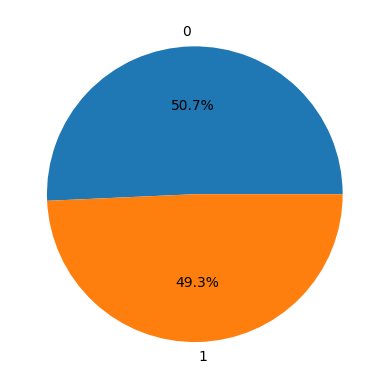

In [36]:
plt.pie(df_TCS['Target'].value_counts().values, 
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

In [37]:
import matplotlib.pyplot as plt

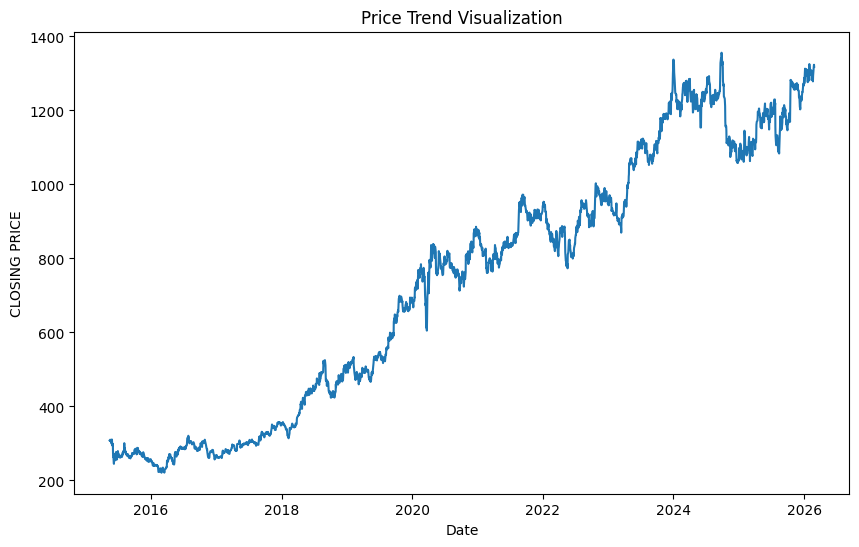

In [38]:
# Price Trend Over the Time
plt.figure(figsize=(10,6))
plt.plot(df_TCS['Date'], df_TCS['Close'], )
plt.title("Price Trend Visualization")
plt.xlabel("Date")
plt.ylabel("CLOSING PRICE")
plt.show()

<Figure size 1000x600 with 0 Axes>

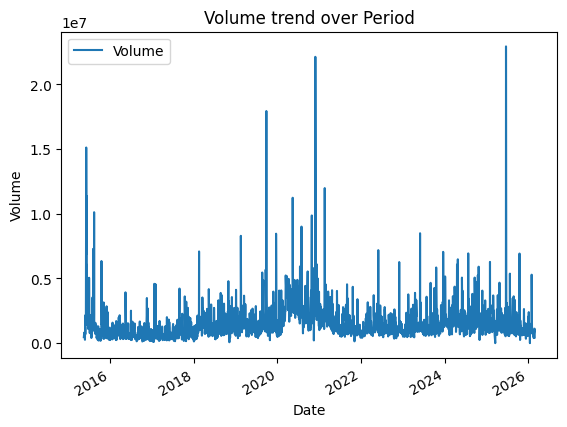

In [39]:
# Volume trend Over Time
plt.figure(figsize=(10,6))
df_TCS.plot(x='Date', y='Volume', kind='line', title="Volume trend over Period")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

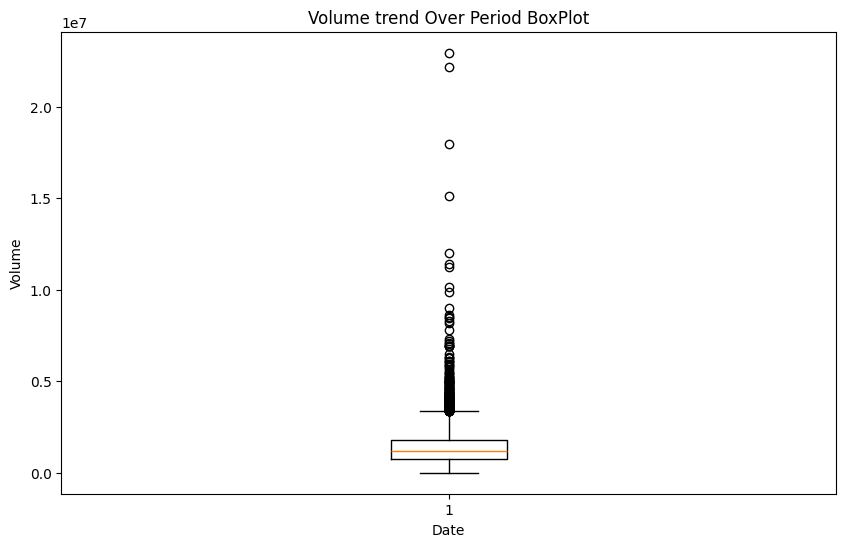

In [40]:
# The Line shows a Outlier in Volume . Check it using Box Plot
plt.figure(figsize=(10,6))
plt.boxplot(df_TCS["Volume"])
plt.title("Volume trend Over Period BoxPlot")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

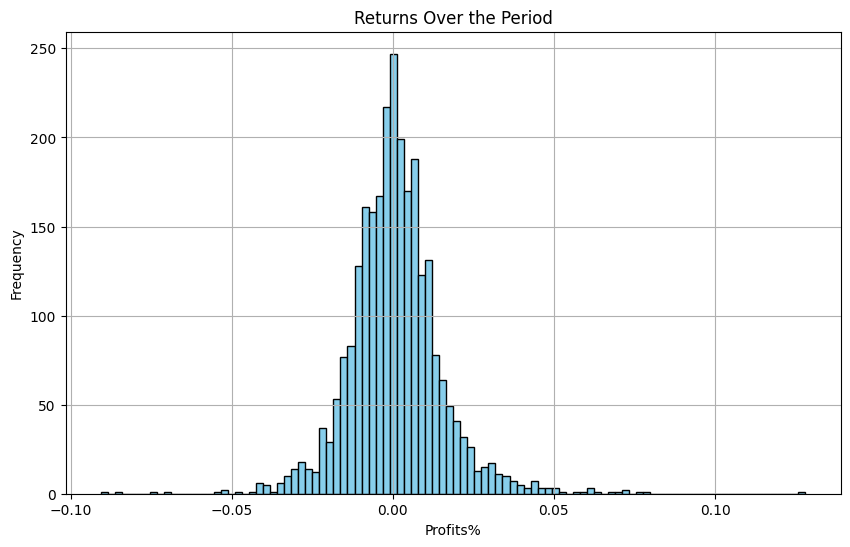

In [41]:
# Visualization of the Returns
plt.figure(figsize=(10,6))
plt.hist(df_TCS['Daily_Returns'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel("Profits%")
plt.ylabel("Frequency")
plt.title("Returns Over the Period")
plt.grid(True) 
plt.show()

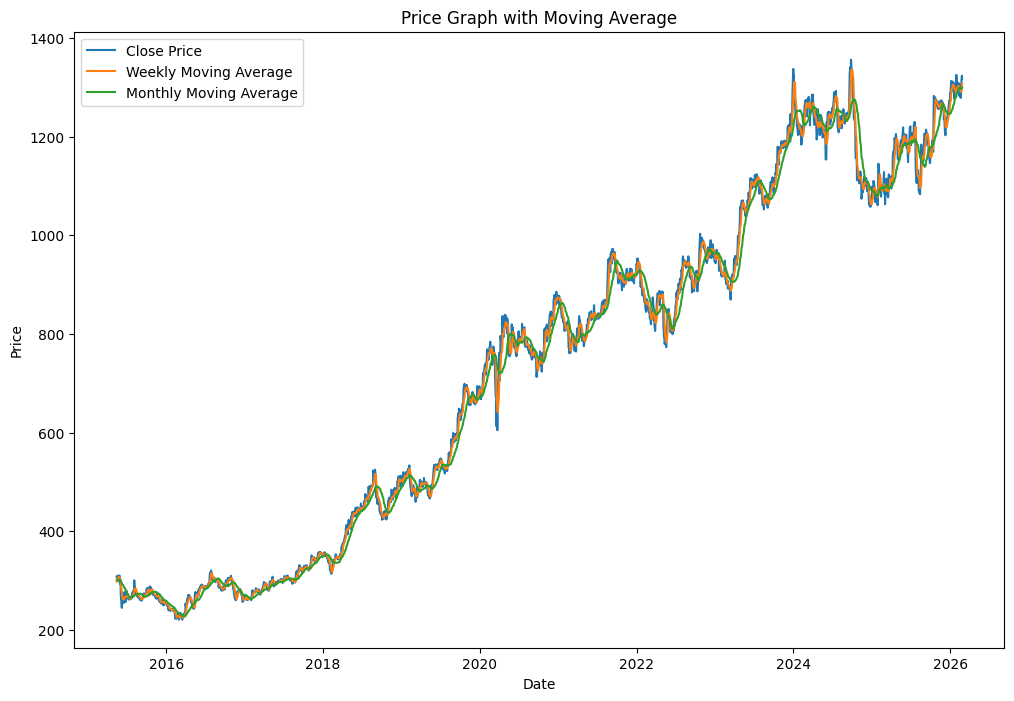

In [42]:
plt.figure(figsize=(12,8))
plt.plot(df_TCS['Date'], df_TCS['Close'], label='Close Price')
plt.plot(df_TCS['Date'], df_TCS['MA_Week'], label='Weekly Moving Average')
plt.plot(df_TCS['Date'], df_TCS['MA_Month'], label="Monthly Moving Average")
plt.title("Price Graph with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

c:\Users\vishe\OneDrive\Desktop\SUL_PROJECT\.venv\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


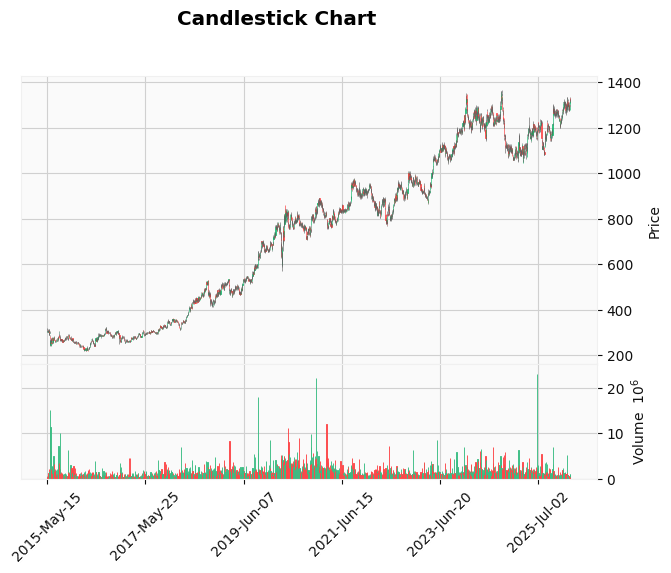

In [43]:
# CandleStick type of Chart
import mplfinance as mpf


# before that set the date column as index column
df_TCS = df_TCS.set_index('Date')
df_TCS = df_TCS.sort_index()

mpf.plot(df_TCS, type='candle', style='yahoo', title=f'Candlestick Chart', volume=True)

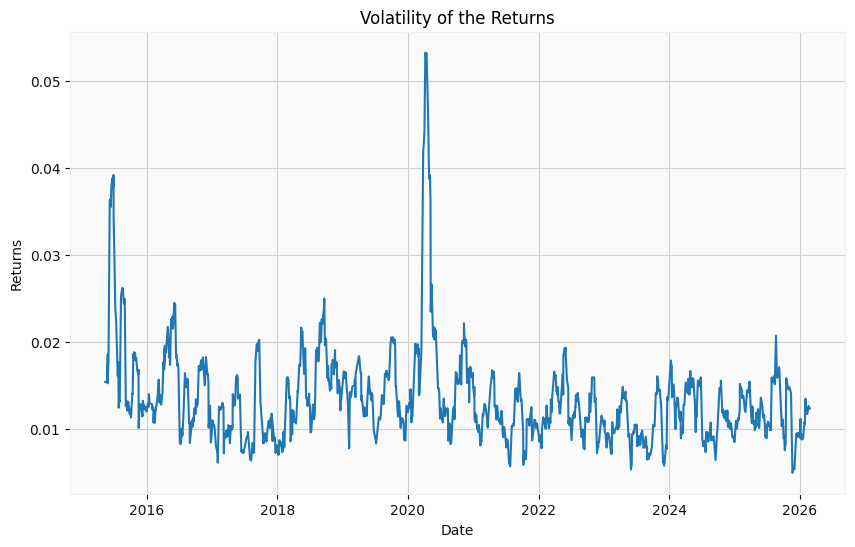

In [44]:
# Plot Date VS Volatily
plt.figure(figsize=(10,6))
plt.plot(df_TCS.index,df_TCS['volatility'])
plt.title("Volatility of the Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

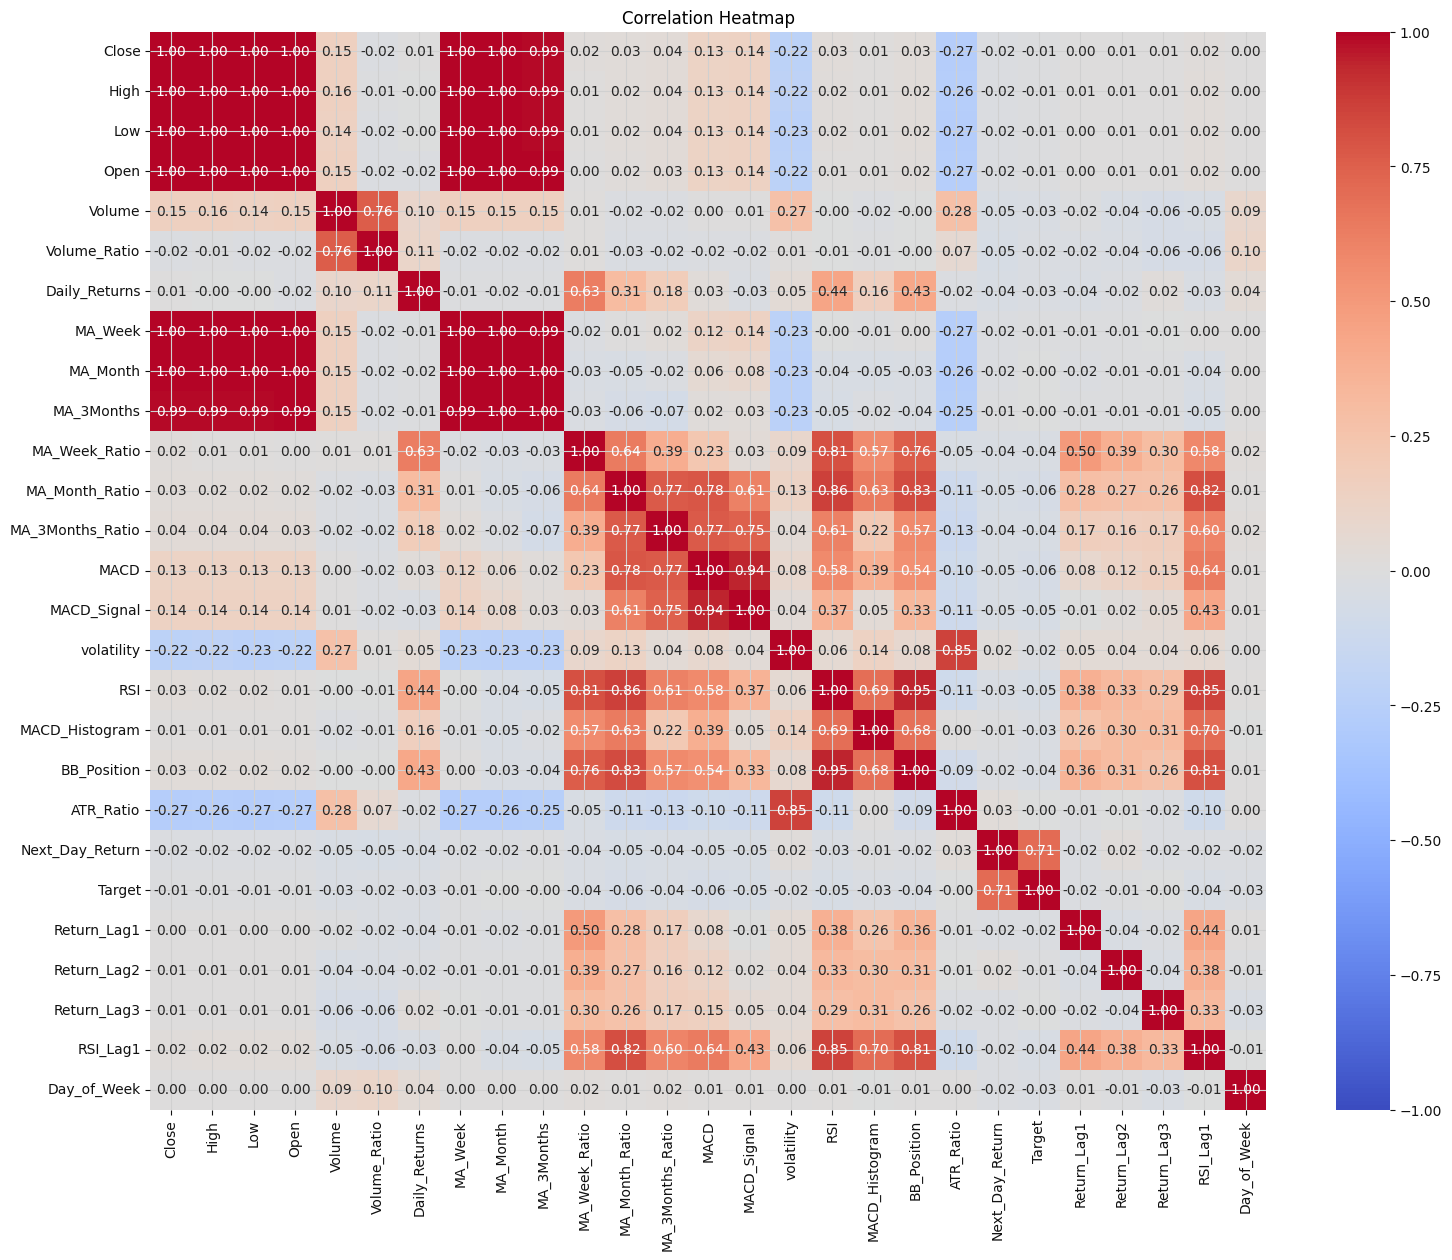

In [45]:
# Check the Correlation between all the calculated values
corr_matrix = df_TCS.select_dtypes('number').corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

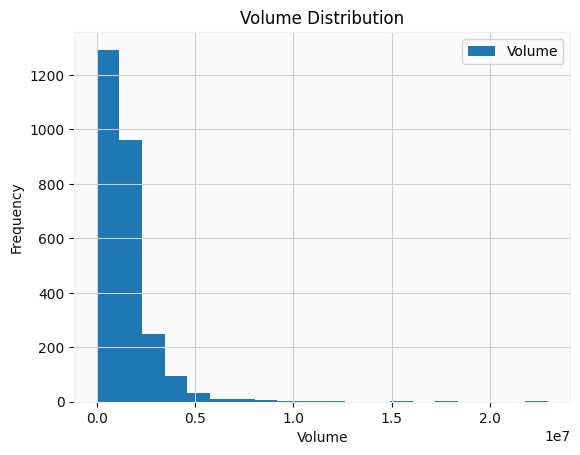

In [46]:
# Plot Histogram for Volume to check for trading activity 
df_TCS.plot(kind='hist', y='Volume', bins=20, title='Volume Distribution')
plt.xlabel("Volume")
plt.show()

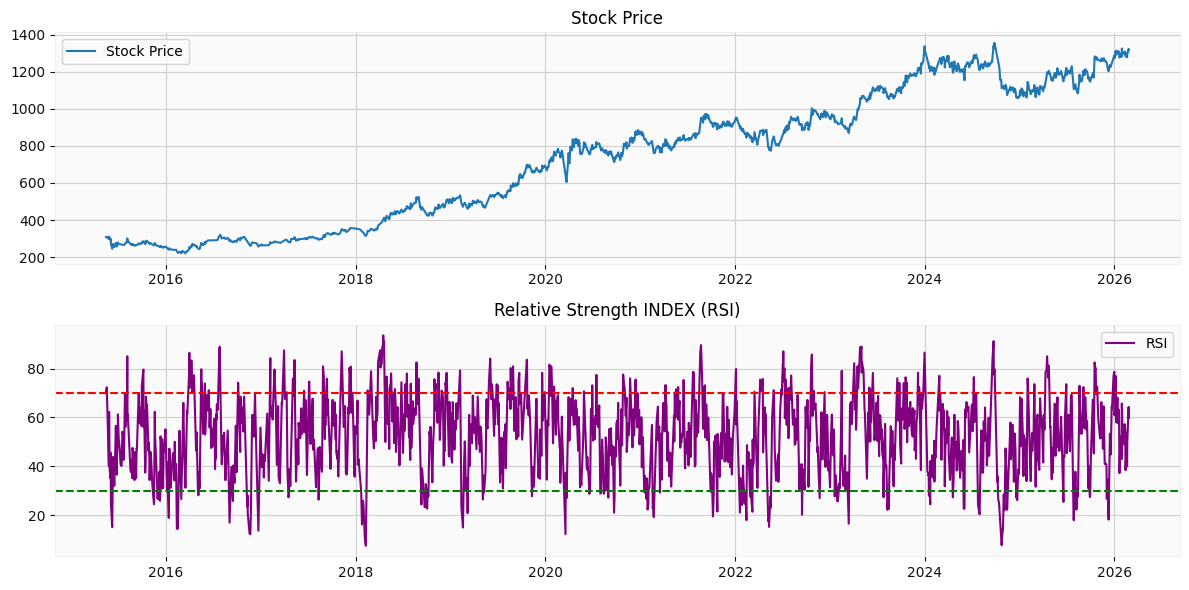

In [47]:
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(df_TCS['Close'], label= "Stock Price")
plt.title("Stock Price")
plt.legend()

plt.subplot(2,1,2)
plt.plot(df_TCS['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', color='red')  # threshold when stock is overbought
plt.axhline(30, linestyle='--', color='green') # threshold when stock is oversold

plt.title("Relative Strength INDEX (RSI)")

plt.legend()
plt.tight_layout()
plt.show()

In [48]:
df_TCS.corr()

,Close,High,Low,Open,Volume,Volume_Ratio,Daily_Returns,MA_Week,MA_Month,MA_3Months,...,MACD_Histogram,BB_Position,ATR_Ratio,Next_Day_Return,Target,Return_Lag1,Return_Lag2,Return_Lag3,RSI_Lag1,Day_of_Week
Close,1.000000,0.999820,0.999799,0.999563,0.150358,-0.016735,0.007435,0.999213,0.996548,0.992000,...,0.014530,0.029247,-0.266193,-0.020161,-0.009481,0.004778,0.005281,0.005279,0.023350,0.003506
High,0.999820,1.000000,0.999711,0.999765,0.155860,-0.012452,-0.003166,0.999327,0.996683,0.992112,...,0.012836,0.024341,-0.260940,-0.019793,-0.009228,0.005427,0.005837,0.005269,0.023864,0.003502
Low,0.999799,0.999711,1.000000,0.999775,0.143168,-0.023381,-0.004493,0.999353,0.996648,0.992007,...,0.011966,0.024031,-0.271374,-0.019600,-0.008753,0.004610,0.005766,0.005524,0.023847,0.002665
Open,0.999563,0.999765,0.999775,1.000000,0.148731,-0.019384,-0.016206,0.999464,0.996825,0.992194,...,0.009517,0.017798,-0.265480,-0.019706,-0.008972,0.003798,0.007058,0.005540,0.023644,0.002875
Volume,0.150358,0.155860,0.143168,0.148731,1.000000,0.762393,0.098180,0.149397,0.150354,0.150027,...,-0.017666,-0.002487,0.280205,-0.046231,-0.031830,-0.015261,-0.041721,-0.055268,-0.046117,0.092894
Volume_Ratio,-0.016735,-0.012452,-0.023381,-0.019384,0.762393,1.000000,0.106845,-0.018048,-0.016676,-0.016107,...,-0.014631,-0.002784,0.068006,-0.046977,-0.023635,-0.023680,-0.036156,-0.061597,-0.057571,0.104216
Daily_Returns,0.007435,-0.003166,-0.004493,-0.016206,0.098180,0.106845,1.000000,-0.014840,-0.015201,-0.013416,...,0.162077,0.426831,-0.019106,-0.039501,-0.026489,-0.038751,-0.016769,0.017573,-0.032408,0.039891
MA_Week,0.999213,0.999327,0.999353,0.999464,0.149397,-0.018048,-0.014840,1.000000,0.997857,0.993172,...,-0.011079,0.000707,-0.265437,-0.018969,-0.008059,-0.012900,-0.008212,-0.005039,0.002048,0.003077
MA_Month,0.996548,0.996683,0.996648,0.996825,0.150354,-0.016676,-0.015201,0.997857,1.000000,0.996575,...,-0.045129,-0.034920,-0.260902,-0.016408,-0.004293,-0.016181,-0.014285,-0.014003,-0.039876,0.002676
MA_3Months,0.992000,0.992112,0.992007,0.992194,0.150027,-0.016107,-0.013416,0.993172,0.996575,1.000000,...,-0.018044,-0.038874,-0.254692,-0.014163,-0.002920,-0.014831,-0.013331,-0.013532,-0.047933,0.001656


### Droping redundant features .

In [49]:
df_TCS.drop(columns=['Next_Day_Return', 'MA_Week', 'MA_Month', 'MA_3Months', 'Volume', 'Date', 'Close', 'High', 'Low', 'Open'], inplace=True, errors='ignore')

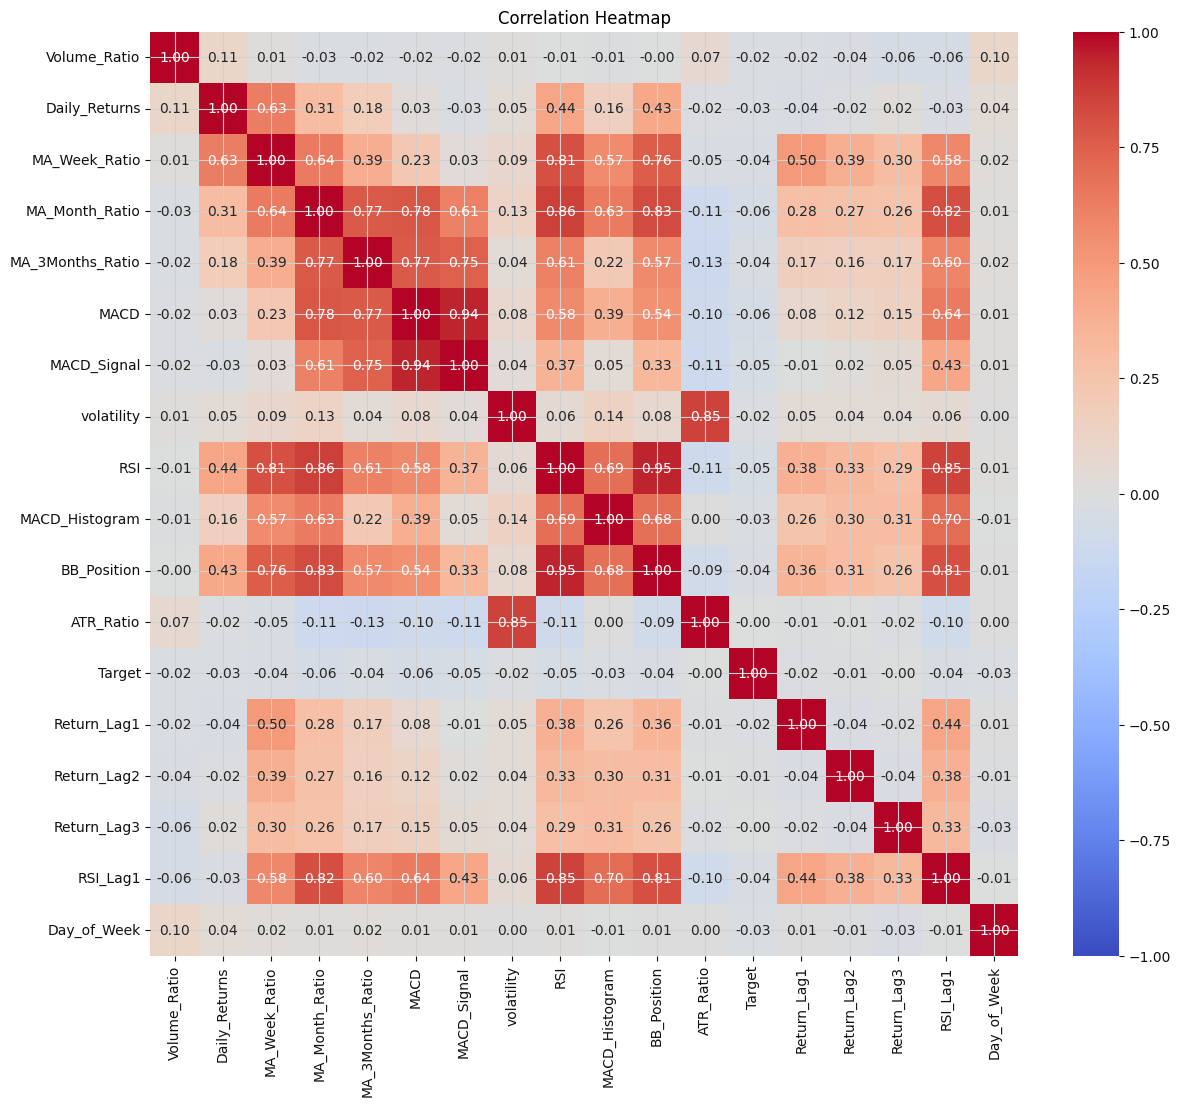

In [50]:
# Check the Correlation between all the calculated values
corr_matrix = df_TCS.select_dtypes('number').corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

### Time Based Train Test Split

In [51]:
df_TCS = df_TCS.sort_index()
split_index = int(len(df_TCS)*0.8)

train = df_TCS.iloc[0:split_index]
test = df_TCS.iloc[split_index: len(df_TCS)]


print(f"Training ENDS: {train.index.max()}")
print(f"Testing Starts: {test.index.min()}")

Training ENDS: 2023-12-29 00:00:00
Testing Starts: 2024-01-01 00:00:00


### Feature Selection - Step 1: Mutual Information

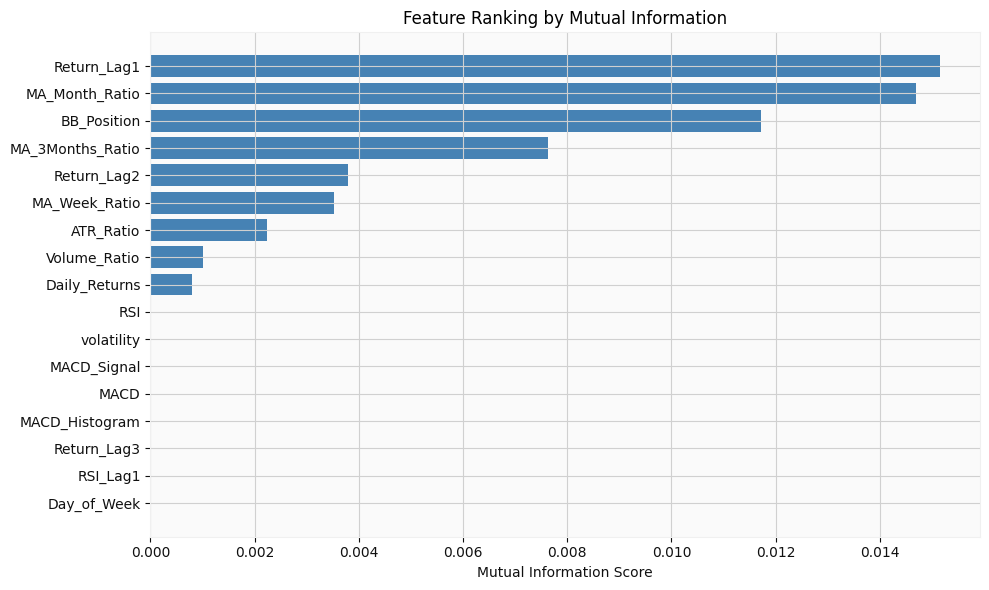

         Feature  MI_Score
     Return_Lag1  0.015164
  MA_Month_Ratio  0.014702
     BB_Position  0.011725
MA_3Months_Ratio  0.007621
     Return_Lag2  0.003792
   MA_Week_Ratio  0.003526
       ATR_Ratio  0.002232
    Volume_Ratio  0.001015
   Daily_Returns  0.000803
             RSI  0.000000
      volatility  0.000000
     MACD_Signal  0.000000
            MACD  0.000000
  MACD_Histogram  0.000000
     Return_Lag3  0.000000
        RSI_Lag1  0.000000
     Day_of_Week  0.000000


In [52]:
from sklearn.feature_selection import mutual_info_classif

candidate_features = [c for c in train.columns if c != 'Target']
mi_scores = mutual_info_classif(train[candidate_features], train['Target'], random_state=42)

mi_ranking = pd.DataFrame({
    'Feature': candidate_features,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(mi_ranking['Feature'], mi_ranking['MI_Score'], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Feature Ranking by Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(mi_ranking.to_string(index=False))

### Feature Selection - Step 2: Random Forest Importance

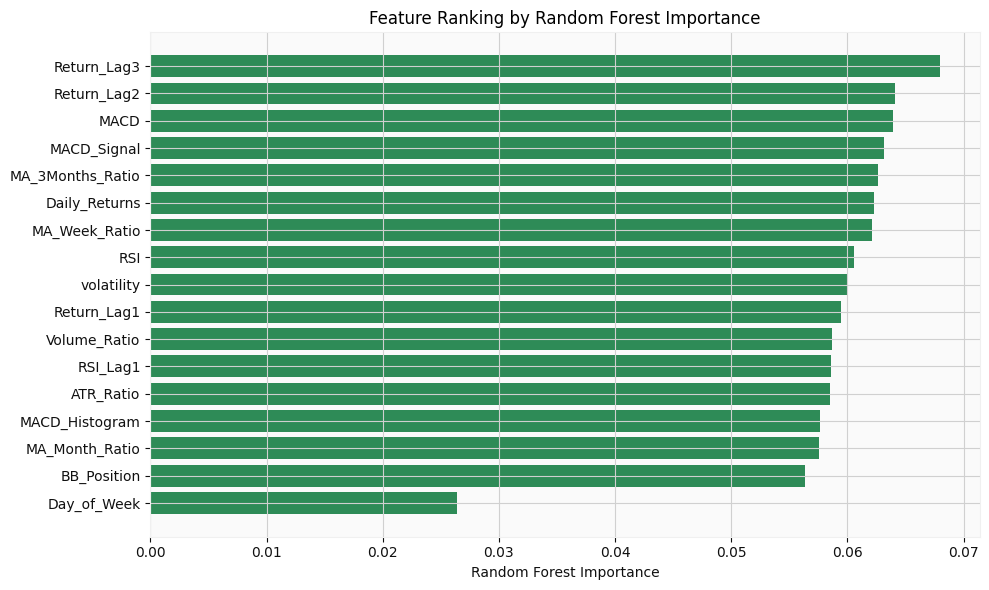

         Feature  MI_Score  RF_Importance  MI_Rank  RF_Rank  Avg_Rank
     Return_Lag2  0.003792       0.064078        5        2       3.5
MA_3Months_Ratio  0.007621       0.062679        4        5       4.5
     Return_Lag1  0.015164       0.059478        1       10       5.5
   MA_Week_Ratio  0.003526       0.062143        6        7       6.5
     Return_Lag3  0.000000       0.068017       13        1       7.0
   Daily_Returns  0.000803       0.062307        9        6       7.5
            MACD  0.000000       0.063898       13        3       8.0
  MA_Month_Ratio  0.014702       0.057539        2       15       8.5
     MACD_Signal  0.000000       0.063153       13        4       8.5
     BB_Position  0.011725       0.056326        3       16       9.5
    Volume_Ratio  0.001015       0.058661        8       11       9.5
       ATR_Ratio  0.002232       0.058513        7       13      10.0
             RSI  0.000000       0.060559       13        8      10.5
      volatility  0.

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_selector.fit(train[candidate_features], train['Target'])

rf_ranking = pd.DataFrame({
    'Feature': candidate_features,
    'RF_Importance': rf_selector.feature_importances_
}).sort_values('RF_Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(rf_ranking['Feature'], rf_ranking['RF_Importance'], color='seagreen')
plt.xlabel('Random Forest Importance')
plt.title('Feature Ranking by Random Forest Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

combined_ranking = mi_ranking.merge(rf_ranking, on='Feature')
combined_ranking['MI_Rank'] = combined_ranking['MI_Score'].rank(ascending=False).astype(int)
combined_ranking['RF_Rank'] = combined_ranking['RF_Importance'].rank(ascending=False).astype(int)
combined_ranking['Avg_Rank'] = (combined_ranking['MI_Rank'] + combined_ranking['RF_Rank']) / 2
combined_ranking = combined_ranking.sort_values('Avg_Rank').reset_index(drop=True)

print(combined_ranking[['Feature', 'MI_Score', 'RF_Importance', 'MI_Rank', 'RF_Rank', 'Avg_Rank']].to_string(index=False))

### Feature Selection - Step 3: RFECV with TimeSeriesSplit

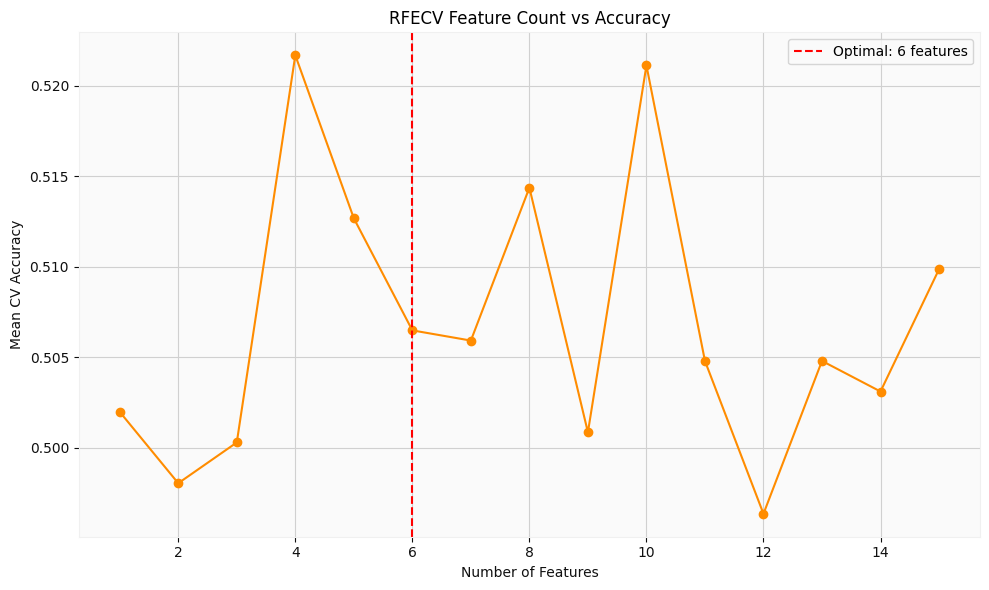

Optimal number of features: 6
Best CV accuracy: 0.5217
Selected features: ['MA_Week_Ratio', 'MA_Month_Ratio', 'MA_3Months_Ratio', 'MACD_Signal', 'ATR_Ratio', 'Return_Lag3']


In [54]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit

rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    step=1,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='accuracy',
    min_features_to_select=3,
    n_jobs=-1
)
rfecv.fit(train[candidate_features], train['Target'])

selected_features = [f for f, keep in zip(candidate_features, rfecv.support_) if keep]

cv_scores = rfecv.cv_results_['mean_test_score']
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', color='darkorange')
plt.axvline(rfecv.n_features_, linestyle='--', color='red', label=f'Optimal: {rfecv.n_features_} features')
plt.xlabel('Number of Features')
plt.ylabel('Mean CV Accuracy')
plt.title('RFECV Feature Count vs Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Optimal number of features: {rfecv.n_features_}')
print(f'Best CV accuracy: {cv_scores.max():.4f}')
print(f'Selected features: {selected_features}')

### Feature Selection - Step 4: Verify New Feature Set Across All Models

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

X_new = df_TCS[selected_features]
y_all = df_TCS['Target']

models_verify = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=14),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_split=6, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'SVC': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
}

tscv_new = TimeSeriesSplit(n_splits=5)
new_results = {name: {'accuracy': [], 'f1_class0': [], 'f1_class1': []} for name in models_verify}

for train_idx, test_idx in tscv_new.split(X_new):
    X_tr, X_te = X_new.iloc[train_idx], X_new.iloc[test_idx]
    y_tr, y_te = y_all.iloc[train_idx], y_all.iloc[test_idx]

    scaler_v = StandardScaler()
    X_tr_s = scaler_v.fit_transform(X_tr)
    X_te_s = scaler_v.transform(X_te)

    for name, model in models_verify.items():
        if name == 'Random Forest':
            model.fit(X_tr, y_tr)
            y_p = model.predict(X_te)
        else:
            model.fit(X_tr_s, y_tr)
            y_p = model.predict(X_te_s)
        new_results[name]['accuracy'].append(accuracy_score(y_te, y_p))
        new_results[name]['f1_class0'].append(f1_score(y_te, y_p, pos_label=0.0))
        new_results[name]['f1_class1'].append(f1_score(y_te, y_p, pos_label=1.0))

baseline_acc = {
    'Logistic Regression': 0.5169,
    'Decision Tree': 0.5110,
    'Random Forest': 0.5192,
    'XGBoost': 0.4994,
    'SVC': 0.5186
}

comparison = pd.DataFrame({
    'Model': list(new_results.keys()),
    'Baseline (4 feat)': [baseline_acc[m] for m in new_results],
    'New (15 feat)': [np.mean(new_results[m]['accuracy']) for m in new_results],
    'F1 (Down)': [np.mean(new_results[m]['f1_class0']) for m in new_results],
    'F1 (Up)': [np.mean(new_results[m]['f1_class1']) for m in new_results],
})
comparison['Improvement'] = comparison['New (15 feat)'] - comparison['Baseline (4 feat)']
comparison = comparison.sort_values('New (15 feat)', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

              Model  Baseline (4 feat)  New (15 feat)  F1 (Down)  F1 (Up)  Improvement
      Decision Tree             0.5110       0.522072   0.461229 0.562599     0.011072
            XGBoost             0.4994       0.518468   0.499539 0.533231     0.019068
Logistic Regression             0.5169       0.517568   0.487834 0.531502     0.000668
      Random Forest             0.5192       0.517117   0.492880 0.537161    -0.002083
                SVC             0.5186       0.501351   0.415600 0.555144    -0.017249


In [56]:
y_train = train['Target']
y_test = test['Target']



features = ['MACD_Signal', 'Return_Lag1', 'Return_Lag3', 'ATR_Ratio', 'RSI_Lag1', 'RSI', 'MACD_Histogram']
# features = ['Return_Lag1', 'MA_3Months_Ratio', 'MA_Week_Ratio', 'volatility', 'Return_Lag3']

X_train = train[features]
X_test = test[features]

In [57]:
df_TCS[features + ['Target']].corr()

,MACD_Signal,Return_Lag1,Return_Lag3,ATR_Ratio,RSI_Lag1,RSI,MACD_Histogram,Target
MACD_Signal,1.000000,-0.006698,0.050611,-0.114288,0.430360,0.365455,0.045714,-0.053111
Return_Lag1,-0.006698,1.000000,-0.017461,-0.008612,0.444545,0.375288,0.256104,-0.017455
Return_Lag3,0.050611,-0.017461,1.000000,-0.016504,0.327259,0.285080,0.308420,-0.000615
ATR_Ratio,-0.114288,-0.008612,-0.016504,1.000000,-0.099255,-0.107109,0.002369,-0.000423
RSI_Lag1,0.430360,0.444545,0.327259,-0.099255,1.000000,0.852288,0.696711,-0.043805
RSI,0.365455,0.375288,0.285080,-0.107109,0.852288,1.000000,0.691935,-0.049500
MACD_Histogram,0.045714,0.256104,0.308420,0.002369,0.696711,0.691935,1.000000,-0.030637
Target,-0.053111,-0.017455,-0.000615,-0.000423,-0.043805,-0.049500,-0.030637,1.000000


### Feature Scaling

In [58]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [59]:
X_trained_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

In [60]:
X_test_Scaled

array([[ 1.93827637,  0.78957388,  0.36267806, ...,  1.7965823 ,
         2.15690463,  3.29200173],
       [ 2.25494759,  1.94372737,  1.32734238, ...,  2.15920893,
         1.82271304,  3.56562808],
       [ 2.50917658, -0.41998148,  0.79111912, ...,  1.8247853 ,
         0.70298276,  2.86001356],
       ...,
       [ 0.04473658,  1.0494729 , -1.20720975, ...,  0.50504953,
         0.63833676,  0.28801222],
       [ 0.102827  ,  0.19544698,  0.74957099, ...,  0.63958669,
         0.73604397,  0.64359323],
       [ 0.16620559,  0.11832613,  1.05099804, ...,  0.73736174,
         0.44859915,  0.70335106]], shape=(533, 7))

### Training Models

In [61]:
# Training A Logistic Regression Model
from sklearn.linear_model import LogisticRegression


model_Logistic_regression = LogisticRegression()

model_Logistic_regression.fit(X_trained_Scaled, y_train)

model_prediction_learning = model_Logistic_regression.predict(X_test_Scaled)

In [62]:
from sklearn.metrics import accuracy_score

prediction_Logistic_regression = accuracy_score(y_test, model_prediction_learning)
print(prediction_Logistic_regression)

0.5422138836772983


In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model_prediction_learning)
print(cm)

[[106 161]
 [ 83 183]]


In [64]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, model_prediction_learning)
print(cr)

              precision    recall  f1-score   support

         0.0       0.56      0.40      0.46       267
         1.0       0.53      0.69      0.60       266

    accuracy                           0.54       533
   macro avg       0.55      0.54      0.53       533
weighted avg       0.55      0.54      0.53       533



In [65]:
'''
Despite a balanced dataset, the model exhibited biased 
predictions due to the weak and noisy nature of stock market signals. 
This suggests that simple linear models are insufficient for capturing 
market dynamics.
'''

'\nDespite a balanced dataset, the model exhibited biased \npredictions due to the weak and noisy nature of stock market signals. \nThis suggests that simple linear models are insufficient for capturing \nmarket dynamics.\n'

### Using the Decision Trees Algorithm 

In [66]:
from sklearn.tree import DecisionTreeClassifier

Decision_Tree_Model = DecisionTreeClassifier(random_state=42, max_depth=14)

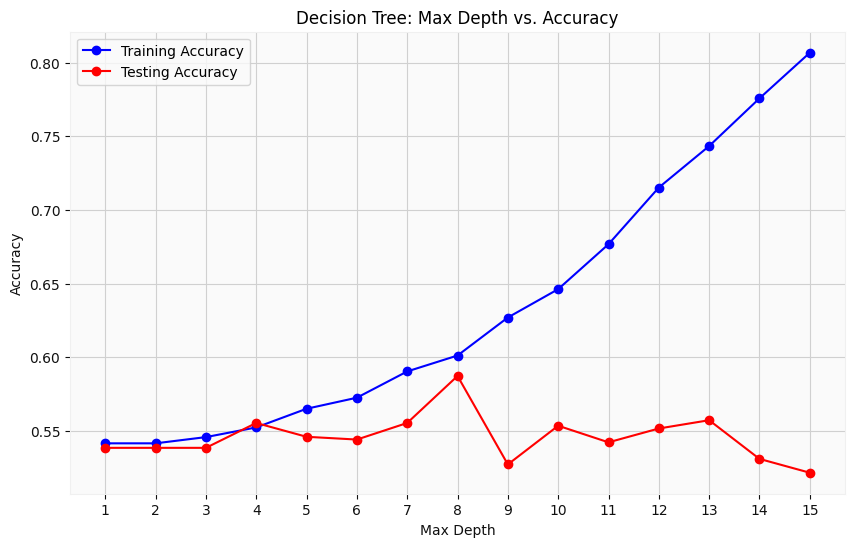

In [67]:
train_accuracies = []
test_accuracies = []

# The range of depths we want to test (from 1 to 15)
depth_range = range(1, 16)

# Loop through each depth
for depth in depth_range:
    # 1. Build and train the tree
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_trained_Scaled, y_train)
    
    # 2. Check accuracy on Training Data
    train_pred = tree.predict(X_trained_Scaled)
    train_acc = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_acc)
    
    # 3. Check accuracy on Testing Data
    test_pred = tree.predict(X_test_Scaled)
    test_acc = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_acc)

# --- Plotting the Results ---
plt.figure(figsize=(10, 6))
plt.plot(depth_range, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(depth_range, test_accuracies, label='Testing Accuracy', marker='o', color='red')

plt.title('Decision Tree: Max Depth vs. Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(depth_range)
plt.legend()
plt.grid(True)
plt.show()

In [68]:
Decision_Tree_Model.fit(X_trained_Scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [69]:
Decision_Tree_Predictions = Decision_Tree_Model.predict(X_test_Scaled)

In [70]:
Decision_Tree_Accuracy = accuracy_score(y_test, Decision_Tree_Predictions)
print(Decision_Tree_Accuracy)

0.5309568480300187


In [71]:
DT_cm = confusion_matrix(y_test, Decision_Tree_Predictions)
print(DT_cm)

[[ 94 173]
 [ 77 189]]


In [72]:
DT_cr = classification_report(y_test, Decision_Tree_Predictions)
print(DT_cr)

              precision    recall  f1-score   support

         0.0       0.55      0.35      0.43       267
         1.0       0.52      0.71      0.60       266

    accuracy                           0.53       533
   macro avg       0.54      0.53      0.52       533
weighted avg       0.54      0.53      0.52       533



In [73]:
# The previous model predicted model would go up 441 times, catching almost all the upward trends but failing miserably at identifying downward trends . 

In [74]:
## The Decision Tree Completely Fixed this blind spot . BY chaining those IF/THEN rules togeather, It successfully identified 163 True Down days (True Negatives). That is an improvement of 240% in protecting capital from bad trades.

### Reciever Operating Characteristic Curve

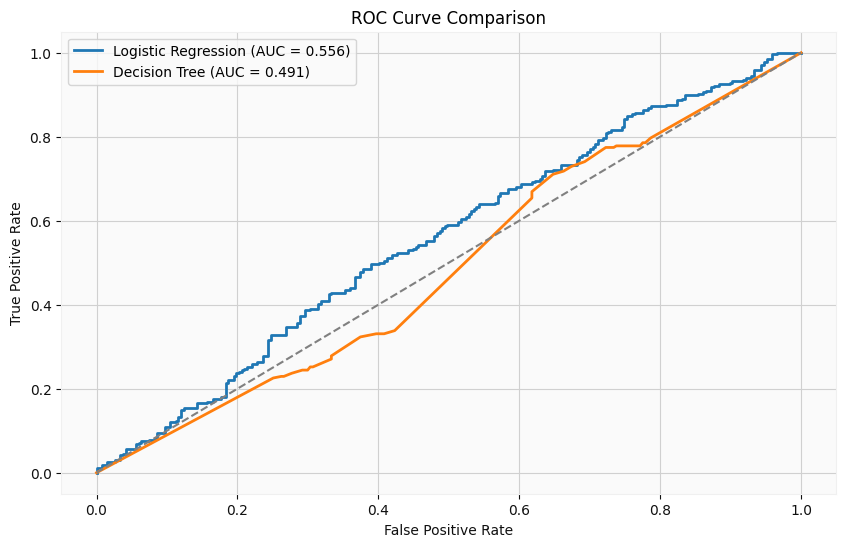

Logistic Regression AUC: 0.5560
Decision Tree AUC: 0.4910


In [75]:
from sklearn.metrics import roc_curve, roc_auc_score

logistic_probs = model_Logistic_regression.predict_proba(X_test_Scaled)[:, 1]
decision_tree_probs = Decision_Tree_Model.predict_proba(X_test_Scaled)[:, 1]

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_probs)
decision_tree_fpr, decision_tree_tpr, _ = roc_curve(y_test, decision_tree_probs)

logistic_auc = roc_auc_score(y_test, logistic_probs)
decision_tree_auc = roc_auc_score(y_test, decision_tree_probs)

plt.figure(figsize=(10, 6))
plt.plot(logistic_fpr, logistic_tpr, label=f'Logistic Regression (AUC = {logistic_auc:.3f})', linewidth=2)
plt.plot(decision_tree_fpr, decision_tree_tpr, label=f'Decision Tree (AUC = {decision_tree_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

print(f"Logistic Regression AUC: {logistic_auc:.4f}")
print(f"Decision Tree AUC: {decision_tree_auc:.4f}")

### Implementing Random Forest 

#### Many decision trees + combine their predictions , Many decision trees + combine their predictions

In [76]:
from sklearn.ensemble import RandomForestClassifier


model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=6,
    random_state=42
)

model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [77]:
y_pred_rf = model_rf.predict(X_test)

In [78]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy : ", accuracy_rf)

Random Forest Accuracy :  0.5534709193245778


In [79]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[120 147]
 [ 91 175]]


In [80]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.57      0.45      0.50       267
         1.0       0.54      0.66      0.60       266

    accuracy                           0.55       533
   macro avg       0.56      0.55      0.55       533
weighted avg       0.56      0.55      0.55       533



In [81]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

          Feature  Importance
0     MACD_Signal    0.149836
2     Return_Lag3    0.149152
5             RSI    0.145299
3       ATR_Ratio    0.141684
1     Return_Lag1    0.140940
4        RSI_Lag1    0.138809
6  MACD_Histogram    0.134280


### Implementing XGBoost

In [82]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_trained_Scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [83]:
y_pred_xgb = model_xgb.predict(X_test_Scaled)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.5046904315196998


In [84]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[123 144]
 [120 146]]


In [85]:
cr_xgb = classification_report(y_test, y_pred_xgb)
print(cr_xgb)

              precision    recall  f1-score   support

         0.0       0.51      0.46      0.48       267
         1.0       0.50      0.55      0.53       266

    accuracy                           0.50       533
   macro avg       0.50      0.50      0.50       533
weighted avg       0.50      0.50      0.50       533



### Implementing Support Vector Classifier (SVC)

In [86]:
from sklearn.svm import SVC

model_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)

model_svc.fit(X_trained_Scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [87]:
y_pred_svc = model_svc.predict(X_test_Scaled)

accuracy_svc = accuracy_score(y_test, y_pred_svc)
print("SVC Accuracy:", accuracy_svc)

SVC Accuracy: 0.5234521575984991


In [88]:
cm_svc = confusion_matrix(y_test, y_pred_svc)
print(cm_svc)

[[ 81 186]
 [ 68 198]]


In [89]:
cr_svc = classification_report(y_test, y_pred_svc)
print(cr_svc)

              precision    recall  f1-score   support

         0.0       0.54      0.30      0.39       267
         1.0       0.52      0.74      0.61       266

    accuracy                           0.52       533
   macro avg       0.53      0.52      0.50       533
weighted avg       0.53      0.52      0.50       533



### TimeSeriesSplit Cross-Validation

In [90]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

features = ['Return_Lag1', 'Volume_Ratio', 'RSI', 'RSI_Lag1']
X = df_TCS[features]
y = df_TCS['Target']

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=14),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_split=6, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'SVC': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
}

tscv = TimeSeriesSplit(n_splits=5)

results = {name: {'accuracy': [], 'f1_class0': [], 'f1_class1': []} for name in models}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)

    for name, model in models.items():
        if name == 'Random Forest':
            model.fit(X_train_fold, y_train_fold)
            y_pred = model.predict(X_test_fold)
        else:
            model.fit(X_train_scaled, y_train_fold)
            y_pred = model.predict(X_test_scaled)

        results[name]['accuracy'].append(accuracy_score(y_test_fold, y_pred))
        results[name]['f1_class0'].append(f1_score(y_test_fold, y_pred, pos_label=0.0))
        results[name]['f1_class1'].append(f1_score(y_test_fold, y_pred, pos_label=1.0))

summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Mean Accuracy': [np.mean(results[m]['accuracy']) for m in results],
    'Std Accuracy': [np.std(results[m]['accuracy']) for m in results],
    'Mean F1 (Down)': [np.mean(results[m]['f1_class0']) for m in results],
    'Mean F1 (Up)': [np.mean(results[m]['f1_class1']) for m in results],
})

summary = summary.sort_values('Mean Accuracy', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

              Model  Mean Accuracy  Std Accuracy  Mean F1 (Down)  Mean F1 (Up)
Logistic Regression       0.508108      0.033425        0.466277      0.526857
      Random Forest       0.505856      0.014144        0.494981      0.514276
      Decision Tree       0.502703      0.016141        0.518893      0.482670
                SVC       0.499099      0.023904        0.464451      0.494798
            XGBoost       0.498198      0.022585        0.498394      0.497157
